In [1]:
import os
import sys

from paths import PROJECT_ROOT
sys.path.insert(0, PROJECT_ROOT)

from paper_figures.cache_utils import activations_cached, connections_cached
from connectome.visualization.random_networks_plots.plot_config import apply_plot_style

plots_dir = os.path.join(PROJECT_ROOT, "plots")
from connectome.visualization.random_networks_plots.plot_config import RANDOMIZATIONS
NUM_PASSES = 3

apply_plot_style()

# Create plots directory if it doesn't exist
os.makedirs(plots_dir, exist_ok=True)

from connectome.data_helpers import load_neuron_coordinates

neuron_position_data = load_neuron_coordinates()

# Heavy cached computations
connections_dict = RANDOMIZATIONS.get_enabled(connections_cached())
activations_dict = RANDOMIZATIONS.get_enabled(activations_cached(NUM_PASSES))

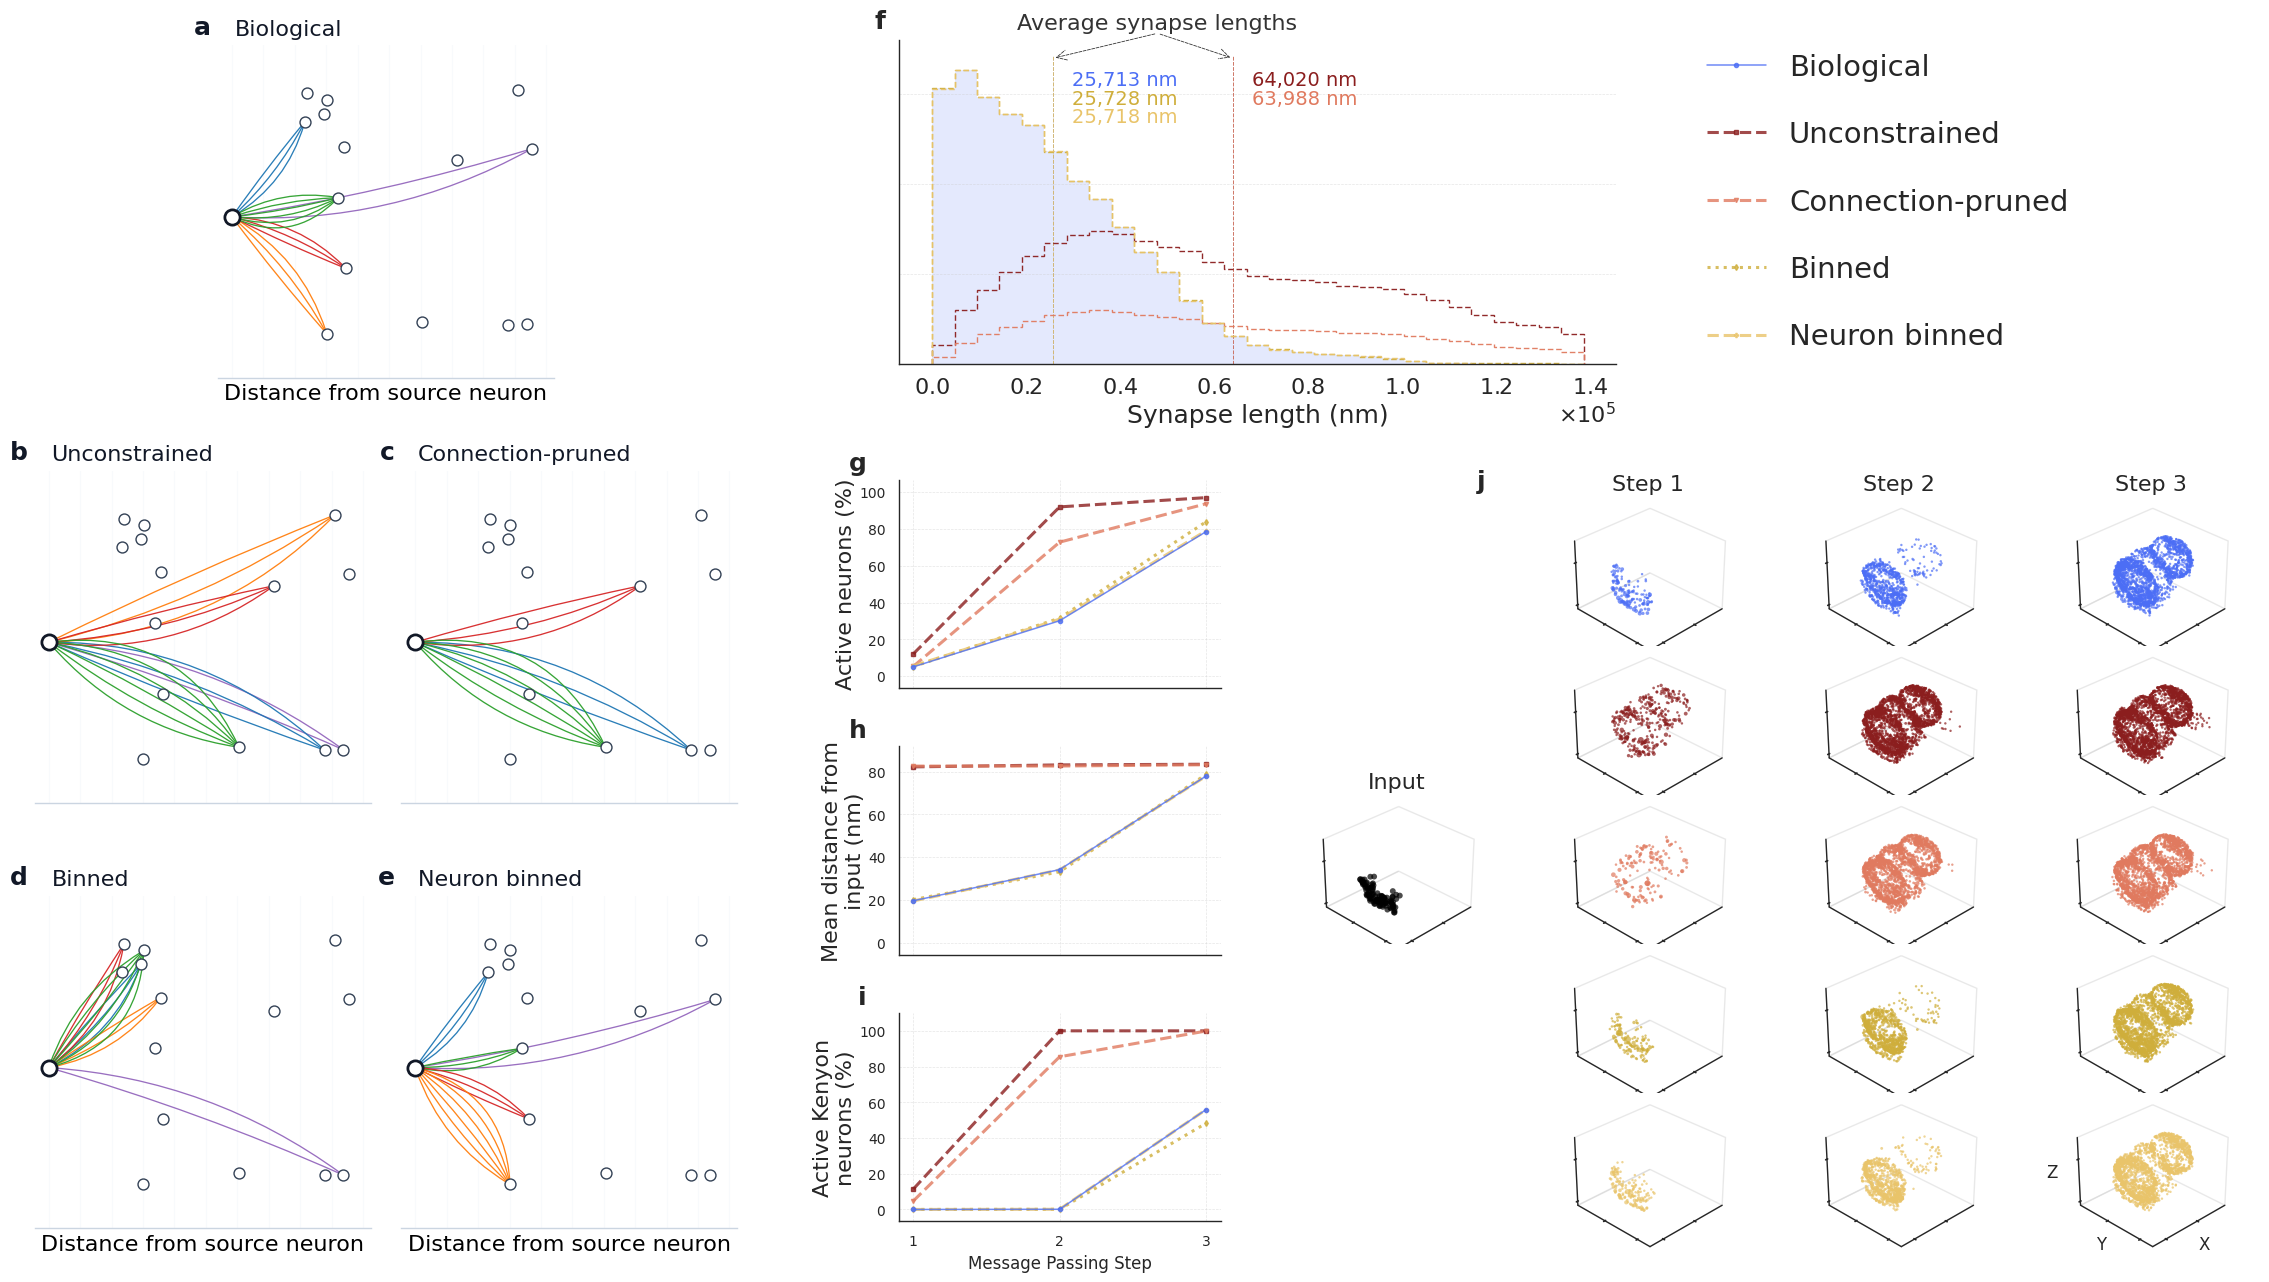

In [10]:
import importlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

plt.close('all')
sns.set_theme(font_scale=1.4, style="white")

from connectome.visualization.random_networks_plots import synapse_distributions
from connectome.visualization.random_networks_plots import activation_plots
from connectome.visualization.random_networks_plots import randomization_strategies
importlib.reload(synapse_distributions)
importlib.reload(activation_plots)
importlib.reload(randomization_strategies)
from connectome.visualization.random_networks_plots.synapse_distributions import plot_overlay_wiring_distributions
from connectome.visualization.random_networks_plots.activation_plots import (
    plot_activation_statistics,
    visualize_steps_separated_compact,
)

apply_plot_style()

width_only_edges = [
    {"id": 0, "target": 1, "syn_count": 3},
    {"id": 1, "target": 4, "syn_count": 6},
    {"id": 2, "target": 6, "syn_count": 3},
    {"id": 3, "target": 9, "syn_count": 3},
    {"id": 4, "target": 19, "syn_count": 2},
]

titles = {
    "biological": RANDOMIZATIONS.label_for("biological"),
    "unconstrained": RANDOMIZATIONS.label_for("unconstrained"),
    "connection_pruned": RANDOMIZATIONS.label_for("connection_pruned"),
    "random_binned": RANDOMIZATIONS.label_for("random_binned"),
    "width_only": RANDOMIZATIONS.label_for("neuron_binned"),
}

fig = plt.figure(figsize=(23, 13))
desired_order = [RANDOMIZATIONS.label_for(key) for key in RANDOMIZATIONS.order]
ordered_connections_dict = {name: connections_dict[name] for name in desired_order}
ordered_activations_dict = {name: activations_dict[name] for name in desired_order}

subfig_left, subfig_right = fig.subfigures(1, 2, width_ratios=[2.0, 4.0], wspace=0.03)

randomization_strategies.plot_randomization_strategies_subfigure(
    subfig_left,
    width_only_edges_override=width_only_edges,
    titles=titles,
    panel_labels=['a', 'b', 'c', 'd', 'e'],
    show_source_label=False,
    apply_theme=False,
)

subfig_top, subfig_bottom = subfig_right.subfigures(
    2,
    1,
    height_ratios=[0.82, 1.68],
    hspace=0.05,
)

gs_top = GridSpec(
    1,
    2,
    figure=subfig_top,
    width_ratios=[3.1, 2.5],
    left=0.08,
    right=0.98,
    top=0.92,
    bottom=0.14,
    wspace=0.10,
)
ax_f = subfig_top.add_subplot(gs_top[0, 0])
plot_overlay_wiring_distributions(
    neuron_position_data,
    ordered_connections_dict,
    bins=30,
    use_density=False,
    x_unit="nm",
    font_size=14,
    show_mean_lines=True,
    show_mean_heading=True,
    show_legend=False,
    ax=ax_f,
)
ax_f.text(-0.02, 1.02, 'f', transform=ax_f.transAxes, fontsize=18, fontweight='bold', va='bottom', ha='right')
ax_f.set_ylabel("")
ax_f.tick_params(axis='y', left=False, labelleft=False)

ax_legend = subfig_top.add_subplot(gs_top[0, 1])
ax_legend.axis('off')

subfig_stats, subfig_steps = subfig_bottom.subfigures(
    1,
    2,
    width_ratios=[2.1, 4.9],
    wspace=0.04,
)

gs_stats = GridSpec(
    3,
    1,
    figure=subfig_stats,
    left=0.27,
    right=0.995,
    top=0.97,
    bottom=0.10,
    hspace=0.28,
)
ax_g = subfig_stats.add_subplot(gs_stats[0, 0])
ax_h = subfig_stats.add_subplot(gs_stats[1, 0], sharex=ax_g)
ax_i = subfig_stats.add_subplot(gs_stats[2, 0], sharex=ax_g)

plot_activation_statistics(
    ordered_activations_dict,
    neuron_position_data,
    num_steps=3,
    axes=(ax_g, ax_h, ax_i),
    show_legend=False,
    show_title=False,
)

ax_g.set_ylabel("Active neurons (%)", fontsize=16, labelpad=2)
ax_h.set_ylabel("Mean distance from\ninput (nm)", fontsize=16, labelpad=2)
ax_i.set_ylabel("Active Kenyon\nneurons (%)", fontsize=16, labelpad=2)

for ax in [ax_g, ax_h, ax_i]:
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    y0, y1 = ax.get_ylim()
    ax.set_ylim(y0 - 0.06 * (y1 - y0), y1)

for ax in [ax_g, ax_h]:
    ax.set_xlabel("")
    ax.tick_params(axis='x', labelbottom=False)

ax_i.set_xlabel("Message Passing Step", fontsize=12)

for ax, label in zip([ax_g, ax_h, ax_i], ['g', 'h', 'i']):
    ax.text(-0.10, 1.02, label, transform=ax.transAxes, fontsize=18, fontweight='bold', va='bottom', ha='right')

handles, labels = ax_g.get_legend_handles_labels()
ax_legend.legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(0.00, 0.5),
    ncol=1,
    fontsize=21,
    frameon=False,
    labelspacing=1.35,
    handlelength=2.0,
)

visualize_steps_separated_compact(
    ordered_activations_dict,
    neuron_position_data,
    num_steps=3,
    max_neurons_percentage=2,
    padding_percent=5,
    short_version=False,
    container=subfig_steps,
    wspace=0.02,
    hspace=-0.08,
    step_title_fontsize=16,
    row_label_fontsize=16,
    coordinate_label_fontsize=12,
    show_row_labels=False,
)
subfig_steps.subplots_adjust(left=0.02, right=0.985, top=0.95, bottom=0.06)
subfig_steps.axes[1].text2D(
    -0.5,
    1.02,
    'j',
    transform=subfig_steps.axes[1].transAxes,
    fontsize=18,
    fontweight='bold',
    va='bottom',
    ha='right',
)

plt.show()

fig.savefig(os.path.join(plots_dir, "figure_2.pdf"), dpi=300)
fig.savefig(os.path.join(plots_dir, "figure_2.png"), dpi=300)